In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lifelines

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv('data/telco.csv')
print(df.shape)
df.head()

(1000, 15)


,ID,region,tenure,age,marital,address,income,ed,retire,gender,voice,internet,forward,custcat,churn
0,1,Zone 2,13,44,Married,9,64,College degree,No,Male,No,No,Yes,Basic service,Yes
1,2,Zone 3,11,33,Married,7,136,Post-undergraduate degree,No,Male,Yes,No,Yes,Total service,Yes
2,3,Zone 3,68,52,Married,24,116,Did not complete high school,No,Female,No,No,No,Plus service,No
3,4,Zone 2,33,33,Unmarried,12,33,High school degree,No,Female,No,No,No,Basic service,Yes
4,5,Zone 2,23,30,Married,9,30,Did not complete high school,No,Male,No,No,Yes,Plus service,No


In [3]:
# Convert churn to numeric: Yes=1, No=0
df['churn'] = (df['churn'] == 'Yes').astype(int)

print("Churn value counts:")
print(df['churn'].value_counts())
print(f"\nChurn rate: {df['churn'].mean():.2%}")

Churn value counts:
churn
0    726
1    274
Name: count, dtype: int64

Churn rate: 27.40%


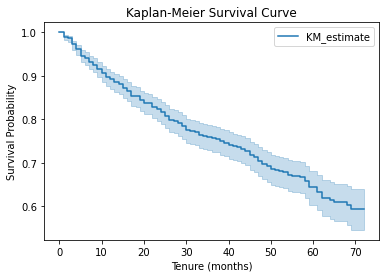

In [4]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(df['tenure'], df['churn'])

kmf.plot_survival_function()
plt.title('Kaplan-Meier Survival Curve')
plt.xlabel('Tenure (months)')
plt.ylabel('Survival Probability')
plt.show()

In [5]:
data = pd.get_dummies(df, 
                      columns=['gender', 'ed', 'marital', 'retire', 'region', 'voice', 'internet', 'forward', 'custcat'], 
                      drop_first=True)
print(data.dtypes)

ID                                 int64
tenure                             int64
age                                int64
address                            int64
income                             int64
churn                              int64
gender_Male                         bool
ed_Did not complete high school     bool
ed_High school degree               bool
ed_Post-undergraduate degree        bool
ed_Some college                     bool
marital_Unmarried                   bool
retire_Yes                          bool
region_Zone 2                       bool
region_Zone 3                       bool
voice_Yes                           bool
internet_Yes                        bool
forward_Yes                         bool
custcat_E-service                   bool
custcat_Plus service                bool
custcat_Total service               bool
dtype: object


In [6]:
data = data.drop(columns=['ID'])

In [7]:
from lifelines import WeibullAFTFitter, LogNormalAFTFitter, LogLogisticAFTFitter

# Fit all models
models = {
    'Weibull': WeibullAFTFitter(),
    'LogNormal': LogNormalAFTFitter(),
    'LogLogistic': LogLogisticAFTFitter()
}

for name, model in models.items():
    model.fit(data, duration_col='tenure', event_col='churn')
    print(f"{name} AIC: {model.AIC_:.2f}")

Weibull AIC: 2964.34
LogNormal AIC: 2954.02
LogLogistic AIC: 2956.21


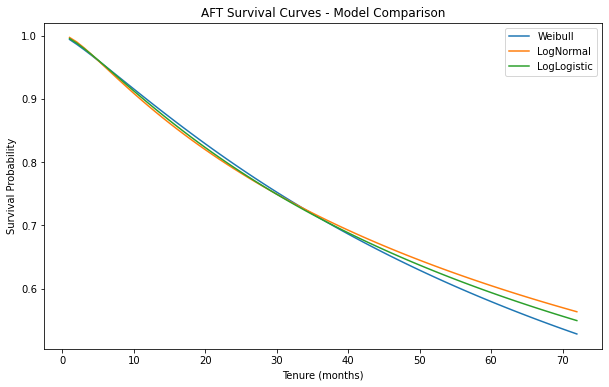

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

for name, model in models.items():
    model.predict_survival_function(data).mean(axis=1).plot(ax=ax, label=name)

plt.title('AFT Survival Curves - Model Comparison')
plt.xlabel('Tenure (months)')
plt.ylabel('Survival Probability')
plt.legend()
plt.show()

## Model Selection

LogNormal is selected as the final model because:
- Lowest AIC (2954.02) among all three models on the full feature set, 
  and further reduced to 2944.20 after keeping only significant features
- Concordance of 0.78 indicates good predictive ability
- The LogNormal distribution allows for a non-monotonic hazard rate, which 
  is realistic for telecom churn — churn risk may peak at certain tenure 
  points rather than constantly increasing or decreasing
- As a decision maker, interpretability also matters: LogNormal coefficients 
  directly describe how features accelerate or decelerate survival time

In [9]:
# First fit LogNormal on all features to find significant ones
full_model = LogNormalAFTFitter()
full_model.fit(data, duration_col='tenure', event_col='churn')

# Extract p-values for mu_ parameters only
pvals = full_model.summary.loc['mu_']['p']

# Keep features with p < 0.05
sig_features = list(pvals[pvals < 0.05].index)
print("Significant features (p < 0.05):")
print(sig_features)

Significant features (p < 0.05):
['address', 'age', 'custcat_E-service', 'custcat_Plus service', 'custcat_Total service', 'internet_Yes', 'marital_Unmarried', 'voice_Yes', 'Intercept']


In [10]:
# Refit final model with only significant features
# Remove 'Intercept' as it is not a data column
sig_features_clean = [f for f in sig_features if f != 'Intercept']
data_final = data[sig_features_clean + ['tenure', 'churn']]

final_model = LogNormalAFTFitter()
final_model.fit(data_final, duration_col='tenure', event_col='churn')
final_model.print_summary()

<lifelines.LogNormalAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'tenure'
                event col = 'churn'
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1462.10
         time fit was run = 2026-05-09 07:50:28 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                              
mu_    address                0.04      1.04      0.01            0.03            0.06                1.03                1.06
       age                    0.04      1.04      0.01            0.02            0.05                1.02                1.05
       custcat_E-service      1.03      2.79      0.17            0.69            1.36                2.00                3.89
       custcat_Plus service   0.82      2.28      0.17            0.49            1.15                1.63                3.17
       custcat_Total service  1.01      2.75      0.21            0.60            1.42                1.83                4.15
       internet_Yes          -0.84      0.43      0.14           -1.11           -0.57                0.33                0.57
       marital_Unmarried     -0.45      0.64      0.11           -0.67           -0.22                0.51                0.80
       voice_Yes             -0.46      0.63      0.17           -0.79           -0.14                0.45                0.87
       Intercept              2.53     12.62      0.24            2.06            3.01                7.84               20.30
sigma_ Intercept              0.28      1.33      0.05            0.19            0.37                1.21                1.45

                              cmp to     z      p  -log2(p)
param  covariate                                           
mu_    address                  0.00  4.84 <0.005     19.56
       age                      0.00  5.75 <0.005     26.78
       custcat_E-service        0.00  6.07 <0.005     29.53
       custcat_Plus service     0.00  4.85 <0.005     19.66
       custcat_Total service    0.00  4.83 <0.005     19.52
       internet_Yes             0.00 -6.08 <0.005     29.63
       marital_Unmarried        0.00 -3.91 <0.005     13.39
       voice_Yes                0.00 -2.78   0.01      7.52
       Intercept                0.00 10.45 <0.005     82.47
sigma_ Intercept                0.00  6.15 <0.005     30.27
---
Concordance = 0.78
AIC = 2944.20
log-likelihood ratio test = 280.83 on 8 df
-log2(p) of ll-ratio test = 183.73

In [11]:
# Get survival probabilities using the final model
surv_probs = final_model.predict_survival_function(data_final, 
                                                    times=list(range(1, 73)))

# Keep only first 24 months
surv_probs_24 = surv_probs.loc[1:24]

MM = 50  # monthly margin in dollars
r = 0.10

clv_values = []
for i, (idx, row) in enumerate(surv_probs_24.iterrows()):
    discounted = row / (1 + r/12) ** i
    clv_values.append(discounted)

clv_df = pd.DataFrame(clv_values)
df['CLV'] = MM * clv_df.sum(axis=0).values

print(df['CLV'].describe())

count    1000.000000
mean      975.251858
std       122.290646
min       352.973151
25%       910.462990
50%      1017.324988
75%      1071.342988
max      1092.533329
Name: CLV, dtype: float64


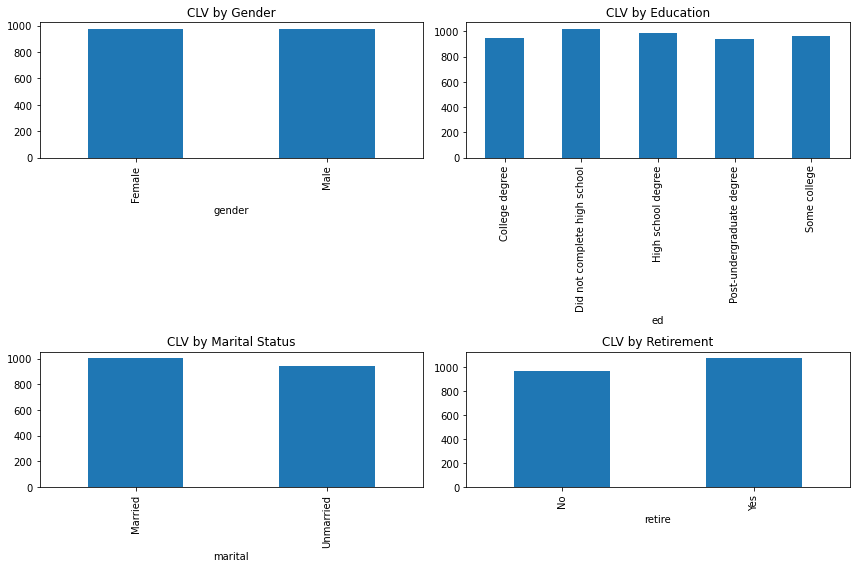

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# By gender
df.groupby('gender')['CLV'].mean().plot(kind='bar', ax=axes[0,0], title='CLV by Gender')

# By education
df.groupby('ed')['CLV'].mean().plot(kind='bar', ax=axes[0,1], title='CLV by Education')

# By marital status
df.groupby('marital')['CLV'].mean().plot(kind='bar', ax=axes[1,0], title='CLV by Marital Status')

# By retirement
df.groupby('retire')['CLV'].mean().plot(kind='bar', ax=axes[1,1], title='CLV by Retirement')

plt.tight_layout()
plt.show()

**Gender:** Female and Male customers have almost identical CLV (~USD 975) — no meaningful difference.

**Education:** "Did not complete high school" customers have the highest CLV, 
followed closely by "High school degree" and "College degree". 
"Post-undergraduate degree" has the lowest CLV. The differences are small 
overall. Note that education was not significant in the final model, so 
this is a descriptive pattern rather than a causal driver.

**Marital Status:** Married customers have slightly higher CLV (\~USD 1000) 
than unmarried customers (\~USD 950) — consistent with the model, where 
being unmarried significantly reduces survival time (exp(coef)=0.64).

**Retirement:** Retired customers have notably higher CLV (\~USD 1050) 
compared to non-retired (\~USD 975). Although retirement was not significant 
in the final model, this likely reflects its correlation with age and address 
stability, both of which are strong positive predictors of survival.

In [13]:
# At-risk customers: those with survival probability < 0.5 within 12 months
surv_12 = final_model.predict_survival_function(data_final).loc[12]
at_risk = df[surv_12.values < 0.5]

print(f"Total customers: {len(df)}")
print(f"At-risk customers (survival < 50% at month 12): {len(at_risk)}")
print(f"Average CLV of at-risk customers: ${at_risk['CLV'].mean():.2f}")
print(f"Total at-risk CLV (annual retention budget): ${at_risk['CLV'].sum():.2f}")

Total customers: 1000
At-risk customers (survival < 50% at month 12): 14
Average CLV of at-risk customers: $512.28
Total at-risk CLV (annual retention budget): $7171.89


## Report

The LogNormal AFT model was selected as the final model (AIC: 2944.20, 
Concordance: 0.78), outperforming Weibull (2964.34) and LogLogistic (2956.21).

**Key factors affecting churn risk:**
- **Customer category** is the strongest predictor — E-service, Plus service, 
  and Total service customers survive 2.79x, 2.28x, and 2.75x longer 
  respectively compared to Basic service customers (baseline)
- **Internet service** customers churn significantly faster (exp(coef)=0.43) — 
  the strongest negative predictor in the model
- **Voice service** customers also churn faster (exp(coef)=0.63)
- **Unmarried customers** churn faster than married customers (exp(coef)=0.64)
- **Age and address stability** both increase survival — each additional year 
  of age or year at the same address multiplies survival time by 1.04x

**Most valuable segments:**
The most valuable customers are E-service or Total service subscribers who 
are married, older, and have lived at the same address for many years. 
"Valuable" is defined as combining high CLV (mean USD 975) with high 
survival probability. Retired customers also show higher average CLV 
(~USD 1050), likely due to their correlation with older age and 
greater address stability.

**Annual retention budget:**
14 customers have less than 50% survival probability within 12 months.
Their combined CLV is USD 7,172, which represents the recommended upper 
bound for the annual retention budget — spending beyond this amount would 
exceed the value of retaining these customers.

**Retention suggestions:**
- Launch targeted retention campaigns for internet and voice service customers, 
  as these are the highest-risk groups according to the model
- Offer loyalty incentives to unmarried customers, particularly in their 
  first 10 months where the survival curve drops fastest
- Consider upselling Basic service customers to higher service tiers 
  (E-service, Plus, or Total), as higher tiers are strongly associated 
  with longer retention
- Focus early engagement programs on new customers — the survival curve 
  shows the steepest drop in the first 10 months